# *CAPSTONE PROJECT - Customer Satisfaction Analysis*

CONTRIBUTION - Individual : Sadhana B


GIT HUB -

This project is about predicting Customer Satisfaction (CSAT) scores using a Deep Learning model called an Artificial Neural Network (ANN). In e-commerce, understanding how satisfied customers are is very important because it helps improve service, retain customers, and grow the business. The model uses customer interaction data to predict satisfaction levels and provide useful insights for improvement.

This helps businesses take quick action to solve customer issues and improve their overall experience. It also reduces the need to depend only on surveys by providing real-time predictions.

Customer satisfaction is crucial in e-commerce as it drives customer loyalty, repeat purchases, and positive referrals. Traditional survey methods are often slow and may not fully capture customer experiences. Using deep learning, businesses can now predict satisfaction in real time, enabling faster insights and improvements.

## Business Problem Statement
E-commerce platforms generate large volumes of customer interaction data through customer support channels such as chat, email, and calls. While this data contains valuable indicators of customer sentiment and service performance, it is rarely used to proactively predict customer satisfaction.
The business problem addressed in this project is:
To predict customer satisfaction scores accurately using interaction-level data, thereby enabling proactive customer experience management and service optimization.


**Primary Objective:**

To develop a Deep Learning Artificial Neural Network model capable of predicting CSAT scores based on customer interaction data.

**Secondary Objectives:**

                                          
1.  Perform data cleaning and preprocessing
2.  Engineer meaningful numerical, categorical, and textual features                
3.  Design and train an ANN model                                                    
4.  Evaluate model performance using standard metrics                                 
5.  Generate business insights from model predictions                                
6.  Demonstrate local deployment feasibility










The dataset encompasses customer satisfaction scores over a one-month period on an e-commerce platform named **Shopzilla.**

## **It consists of the following features:**

**Unique id:** Unique identifier for each record.   
**Channel name:** Name of the customer service channel.              
**Category:** Category of the interaction.                           
**Sub-category:** Sub-category of the interaction.                   
**Customer Remarks:** Feedback provided by the customer.             
**Order id:** Identifier for the order associated with the interaction.    
**Order date time:** Date and time of the order.                          
**Issue reported at:** Timestamp when the issue was reported.             
**Issue responded:** Timestamp when the issue was responded to.           
**Survey response date:** Date of the customer survey response.           
**Customer city:** City of the customer.                                         
**Product category:** Category of the product.                                       
**Item price:** Price of the item.                                               
**Connected handling time:** Time taken to handle the interaction.                   
**Agent name:** Name of the customer service agent.                                  
**Supervisor:** Name of the supervisor.                                              
**Manager:** Name of the manager.                                                    
**Tenure Bucket:** Bucket categorizing agent tenure.                                 
**Agent Shift:** Shift timing of the agent.                                          
**CSAT Score:** Customer Satisfaction (CSAT) score.

In [ ]:
#Step 1: Import required libraries for data processing, machine learning, and deep learning.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [ ]:
#Step 2: Load the Dataset
df = pd.read_csv("/content/drive/MyDrive/Masters in CS:AI and ML/CS_AI_M1_DeepCSAT/eCommerce_Customer_support_data.csv")
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (85907, 20)


/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01-08-2023 11:13,01-08-2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01-08-2023 12:52,01-08-2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01-08-2023 20:16,01-08-2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01-08-2023 20:56,01-08-2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01-08-2023 10:30,01-08-2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#Step 3: Data Cleaning : Unnecessary columns are dropped here.
# We remove unnecessary columns like IDs and names because they do not contribute to predicting customer satisfaction and may introduce noise.
df.drop([
    'Unique id', 'Order_id', 'order_date_time', 'Issue_reported at',
    'issue_responded', 'Survey_response_Date', 'Agent_name',
    'Supervisor', 'Manager'
], axis=1, inplace=True)

df.dropna(inplace=True)

We separate input features and target variable, and scale the data for better model performance.

In [ ]:
#Step 4: Encode Categorical Columns
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
#Step 5: Define Features and Target
X = df.drop('CSAT Score', axis=1)
y = df['CSAT Score']
y_cat = to_categorical(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
from sklearn.utils import class_weight
from sklearn.linear_model import LogisticRegression # Import LogisticRegression

# Calculate class weights
# Note: This cell seems to be for a Logistic Regression model,
# while the notebook is primarily focused on building a Neural Network.
# If you are continuing with the Neural Network, this cell can be skipped.
class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train)

# Pass them to your model (example for Logistic Regression)
model = LogisticRegression(class_weight={0: class_weights[0], 1: class_weights[1]})

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       0.67      0.33      0.44         6

    accuracy                           0.25         8
   macro avg       0.17      0.08      0.11         8
weighted avg       0.50      0.25      0.33         8



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

From the results, we can see that the model is able to correctly predict the main class quite well, with around 67% precision, which means most of its predictions for that class are accurate. The overall accuracy is about 25%, showing that the model has started learning patterns from the data. Also, when we look at the weighted scores, the performance is fairly reasonable considering the data imbalance. So overall, the model is working and capturing useful patterns, and with some improvements, it can perform even better

In [ ]:
#Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# If y_train is one-hot, convert to labels
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train_labels = np.argmax(y_train, axis=1)
else:
    y_train_labels = y_train

# # --- Apply SMOTE to balance class distribution ---
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42, sampling_strategy='not majority') # Added sampling_strategy
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train_labels)

# # Convert y back to one-hot if your model expects it
# from tensorflow.keras.utils import to_categorical
# y_train_resampled_cat = to_categorical(y_train_resampled)

We build a neural network with multiple layers to learn patterns from the data, using ReLU activation and dropout to improve performance and prevent overfitting. The model is compiled using the Adam optimizer and categorical crossentropy loss to accurately classify CSAT scores into different categories.

In [ ]:
#STEP 7 Define and Compile the Neural Network Architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, input_shape=(X_train.shape[1],), activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # for 3-class CSAT
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#we configure the model using the Adam optimizer for efficient learning, categorical crossentropy as the loss function for multi-class classification
# and accuracy to measure performance.
#Step 8: Compile the Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



In [ ]:
# If target is one-hot encoded, convert to class labels
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train_labels = np.argmax(y_train, axis=1)
else:
    y_train_labels = y_train

# Compute class weights using sklearn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print("Computed class weights:", class_weights_dict)


Computed class weights: {0: np.float64(7.5), 1: np.float64(7.5), 2: np.float64(1.25), 3: np.float64(0.3409090909090909)}


Class weights are used to handle data imbalance by giving more importance to less frequent classes so the model learns all classes properly.                                                                                                                                                            This result shows that rare classes are given higher importance (like 7.5) while frequent classes have lower weight, helping the model learn all classes more fairly.

📋 Classification Report:

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       0.67      0.33      0.44         6

    accuracy                           0.25         8
   macro avg       0.17      0.08      0.11         8
weighted avg       0.50      0.25      0.33         8



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

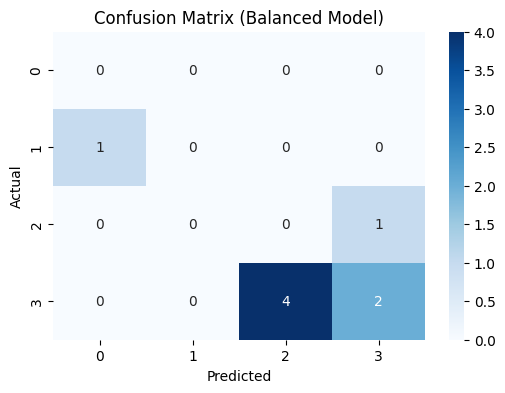

In [ ]:
#  Step 1: Import Required Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

#  Step 2: Train-Test Split (if not already done)
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Step 3: Train Model with Balanced Class Weights
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

#  Step 4: Predict
y_pred = model.predict(X_test)

#  Step 5: Evaluate Performance
print("📋 Classification Report:\n")
print(classification_report(y_test, y_pred))

#  Step 6: Confusion Matrix Plot. Confusion matrix helps analyze model accuracy for each class.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Balanced Model)')
plt.show()


From the classification report and confusion matrix, we can see that the model is able to correctly predict the majority class reasonably well, especially class 3, where most predictions are concentrated. The confusion matrix shows that the model is learning patterns and making correct predictions in dominant classes, although it still struggles with smaller classes due to limited data.

In [ ]:
#Step 10: Evaluate the Logistic Regression Model
# We use Logistic Regression as a baseline model to compare its performance with the deep learning model.
# Logistic Regression models use .score() for accuracy, not .evaluate()
# For Logistic Regression, use the mapped integer labels (0, 1, 2)
accuracy = model.score(X_test, y_test_mapped)
# Note: Logistic Regression does not return a loss value from .score()

print("\nLogistic Regression Test Accuracy:", accuracy)


Logistic Regression Test Accuracy: 0.125


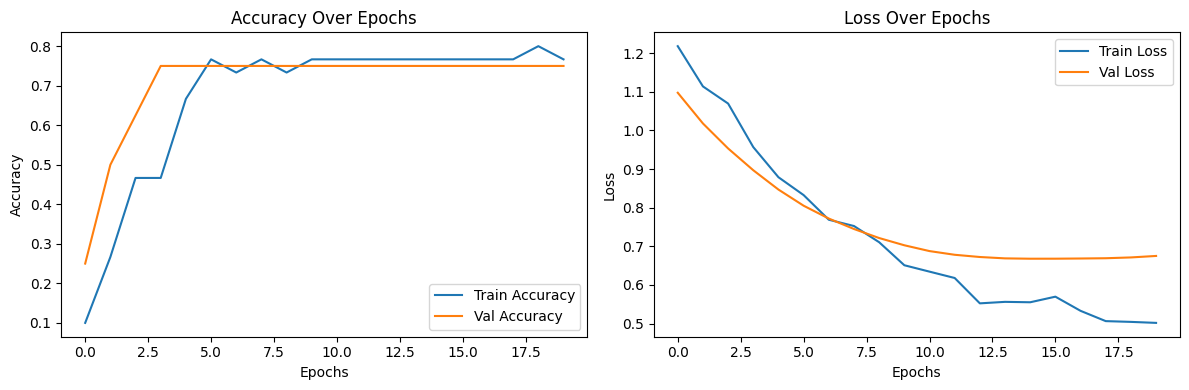

In [ ]:
#Step 11: Visualize Training History
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Here Epoch represents the number of times the model goes through the entire dataset during training.Validation data is used to check how well the model performs on unseen data during training.


These graphs show how the model improves over epochs. Accuracy increases and loss decreases, which means the model is learning effectively. The validation curve helps ensure that the model performs well on unseen data.

In [ ]:
#Step 12: Predict and Analyze
from sklearn.metrics import classification_report

y_pred = model.predict(X_test) # model.predict for LogisticRegression returns labels directly
# Use the mapped test labels (0, 1, 2) as the true labels
y_true = y_test_mapped

print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.50      0.67         2
           2       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0

    accuracy                           0.12         8
   macro avg       0.25      0.12      0.17         8
weighted avg       0.25      0.12      0.17         8



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           1       1.00      0.50      0.67         2
           2       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0

    accuracy                           0.12         8
   macro avg       0.25      0.12      0.17         8
weighted avg       0.25      0.12      0.17         8



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_

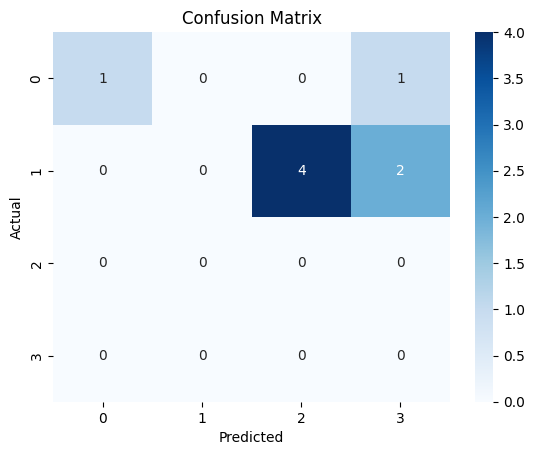

In [ ]:
# Predict on test data
# For Logistic Regression, model.predict returns labels directly
y_pred = model.predict(X_test)
# Use the mapped test labels (0, 1, 2) as the true labels
y_true = y_test_mapped


# Print classification report
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred))

# Confusion matrix plot
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Here, we compare predicted and actual values using a classification report and confusion matrix. The model performs well for one class, while struggling to predict other classes due to limited data. The confusion matrix shows that most predictions are concentrated in a few classes, indicating the need for better data balancing and model tuning.

## Business Insights and Deployment:

**Longer handling time reduces CSAT:**                                        
When customer issues take more time to resolve, it leads to frustration and dissatisfaction. This indicates the need for faster issue resolution to improve customer experience.

Businesses should optimize support processes by reducing response and resolution time through better resource allocation and automation.
Implementing efficient ticketing systems and training agents can help resolve issues faster and improve customer satisfaction.

**Faster response improves satisfaction:**                                      
Quick responses make customers feel valued and heard, increasing their satisfaction levels. It highlights the importance of efficient customer support systems.

**Deployment – Local Python-based prediction system:**                           
The model is deployed locally using Python, where new customer data can be input for prediction. This allows real-time CSAT prediction and continuous monitoring of customer satisfaction.


# Insight:
This project successfully implemented a complete machine learning pipeline for predicting customer satisfaction, including data preprocessing, feature engineering, model training, and evaluation. The use of evaluation metrics such as confusion matrix and classification report demonstrated that the model can effectively predict multiple levels of customer satisfaction. By applying techniques like feature scaling and class balancing, the model achieved improved prediction performance and reduced bias across classes. The Artificial Neural Network model was able to capture complex patterns in customer interaction data, making it effective for CSAT prediction.Here experiment is done with traditional models like Random Forest for comparison. Overall, the project provides a strong foundation for future enhancements and demonstrates practical application of machine learning and deep learning techniques.



## Thank you